In [337]:
import kagglehub
import os
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')
# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/medical-insurance-cost-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/solow/.cache/kagglehub/datasets/mosapabdelghany/medical-insurance-cost-dataset/versions/1


In [338]:
file=os.listdir(path=path)
file=os.path.join(path,file[0])
df=pd.read_csv(file)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [339]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [340]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [341]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [342]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [343]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [344]:
df_original=df.copy()

In [345]:
df['charges']=round(df['charges'],2)
df['bmi']=round(df['bmi'],2)

In [346]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55
1334,18,female,31.92,0,no,northeast,2205.98
1335,18,female,36.85,0,no,southeast,1629.83
1336,21,female,25.80,0,no,southwest,2007.94


In [347]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [348]:
df['sex']=df['sex'].map({'female':0,'male':1})
df['smoker']=df['smoker'].map({'no':0,'yes':1})

In [349]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,southwest,16884.92
1,18,1,33.77,1,0,southeast,1725.55
2,28,1,33.00,3,0,southeast,4449.46
3,33,1,22.70,0,0,northwest,21984.47
4,32,1,28.88,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,1,30.97,3,0,northwest,10600.55
1334,18,0,31.92,0,0,northeast,2205.98
1335,18,0,36.85,0,0,southeast,1629.83
1336,21,0,25.80,0,0,southwest,2007.94


In [350]:
df[df["children"].between(0, 5)]["sex"].value_counts()

sex
1    676
0    662
Name: count, dtype: int64

In [351]:
pd.crosstab(df["children"], df["sex"])

sex,0,1
children,,
0,289,285
1,158,166
2,119,121
3,77,80
4,11,14
5,8,10


In [352]:
numerical_col=['age','bmi']

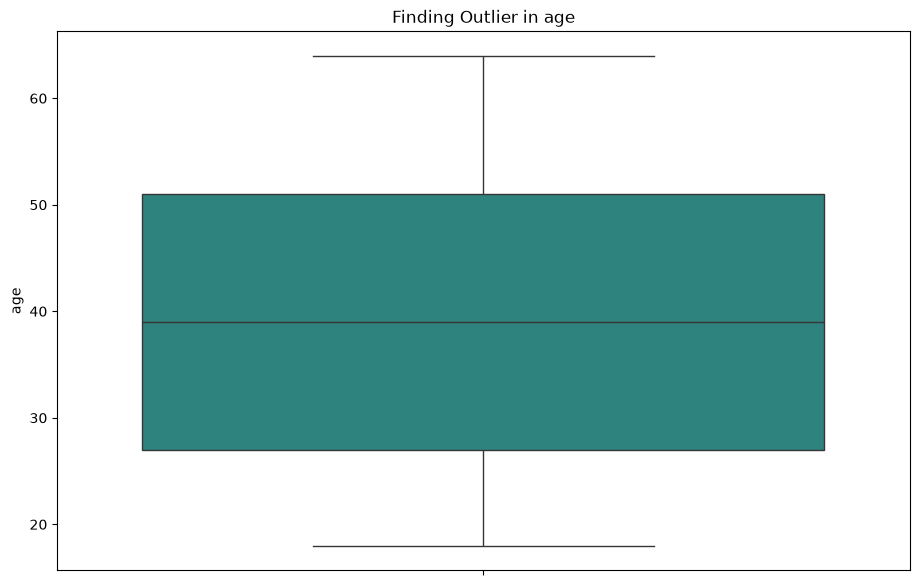

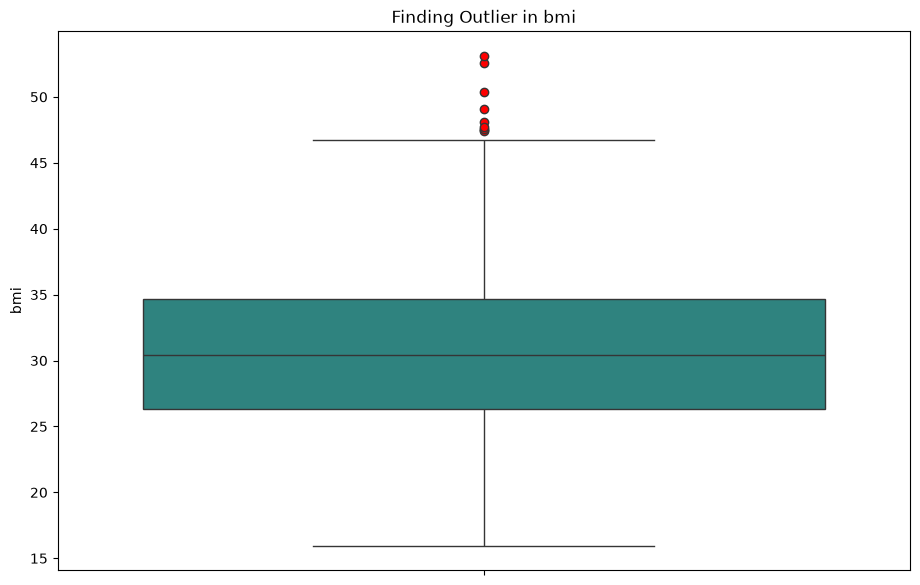

In [353]:
import seaborn as sns
import matplotlib.pyplot as plt
for each in numerical_col:
    fig,ax=plt.subplots(figsize=(11,7))
    sns.boxplot(df[each],palette='viridis',ax=ax,flierprops={"markerfacecolor": "red"})
    ax.set_title(f'Finding Outlier in {each}')
    plt.show()

In [354]:
q1 = df["bmi"].quantile(0.25)
q3 = df["bmi"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

bmi_outliers = df[(df["bmi"] < lower) |(df["bmi"] > upper)]

print(len(bmi_outliers))

9


<Axes: xlabel='charges', ylabel='Count'>

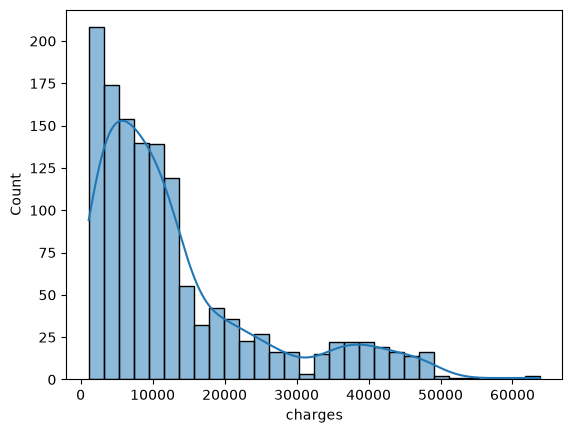

In [355]:
sns.histplot(df["charges"], kde=True)

In [356]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 73.3 KB


In [357]:
((1338-1191)/1191)*100 

12.34256926952141

In [358]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,southwest,16884.92
1,18,1,33.77,1,0,southeast,1725.55
2,28,1,33.00,3,0,southeast,4449.46
3,33,1,22.70,0,0,northwest,21984.47
4,32,1,28.88,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,1,30.97,3,0,northwest,10600.55
1334,18,0,31.92,0,0,northeast,2205.98
1335,18,0,36.85,0,0,southeast,1629.83
1336,21,0,25.80,0,0,southwest,2007.94


In [359]:
df['bmi'].skew()

np.float64(0.28410490896525215)

In [360]:
numerical_col
binary_col=['sex','smoker']
ordinal_col=['region','children']
target='charges'

In [361]:
feature=numerical_col+binary_col+ordinal_col
len(feature)

6

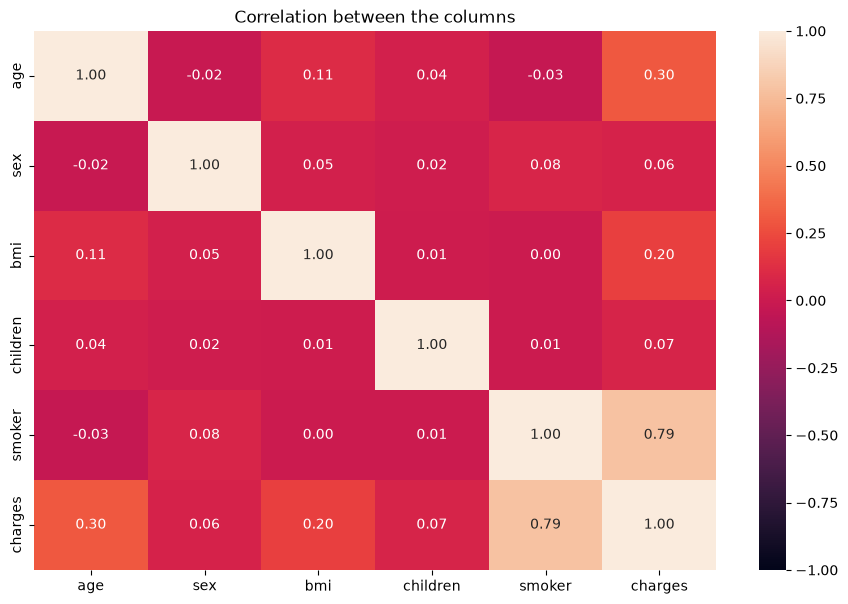

In [362]:
fig,ax=plt.subplots(figsize=(11,7))
sns.heatmap(df.corr(numeric_only=True),vmax=1,vmin=-1,annot=True,ax=ax,fmt='.2f')
ax.set_title('Correlation between the columns')
plt.show()

In [363]:
x=df[feature]
y=df['charges']

In [366]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=24,test_size=.20)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,OneHotEncoder